In [39]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [40]:
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [42]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [43]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [44]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [45]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [46]:
model = timm.create_model(
    'beit_base_patch16_224',
    pretrained=True,
    num_classes=len(class_names)   # ✅ IMPORTANT
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/350M [00:00<?, ?B/s]

In [47]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [48]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [49]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_vit.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_vit.pth"))
    return model

In [50]:
model = train_model(model, train_loader, val_loader, epochs=10)

/tmp/ipykernel_55/983819229.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10
Train Loss: 0.7372 | Train Acc: 0.7365
Val Loss: 0.6388 | Val Acc: 0.7661 | Val F1: 0.7444
Best F1: 0.7444
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10
Train Loss: 0.5359 | Train Acc: 0.7939
Val Loss: 0.5946 | Val Acc: 0.7537 | Val F1: 0.7218
Best F1: 0.7444
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10
Train Loss: 0.4267 | Train Acc: 0.8299
Val Loss: 0.4490 | Val Acc: 0.8162 | Val F1: 0.8118
Best F1: 0.8118
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10
Train Loss: 0.4222 | Train Acc: 0.8295
Val Loss: 0.4433 | Val Acc: 0.8162 | Val F1: 0.8129
Best F1: 0.8129
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10
Train Loss: 0.4142 | Train Acc: 0.8300
Val Loss: 0.4349 | Val Acc: 0.8267 | Val F1: 0.8219
Best F1: 0.8219
--------------------------------------------------


In [51]:
for param in model.blocks[-2:].parameters():
    param.requires_grad = True

In [52]:
model = train_model(model, train_loader, val_loader, epochs=20)

/tmp/ipykernel_55/983819229.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20
Train Loss: 0.4662 | Train Acc: 0.8058
Val Loss: 0.4277 | Val Acc: 0.8156 | Val F1: 0.8079
Best F1: 0.8079
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/20
Train Loss: 0.3942 | Train Acc: 0.8340
Val Loss: 0.4444 | Val Acc: 0.8001 | Val F1: 0.7827
Best F1: 0.8079
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 18/20
Train Loss: 0.0900 | Train Acc: 0.9658
Val Loss: 0.2787 | Val Acc: 0.8973 | Val F1: 0.8968
Best F1: 0.9001
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20
Train Loss: 0.0862 | Train Acc: 0.9677
Val Loss: 0.2763 | Val Acc: 0.8979 | Val F1: 0.8972
Best F1: 0.9001
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20
Train Loss: 0.0830 | Train Acc: 0.9690
Val Loss: 0.2648 | Val Acc: 0.9022 | Val F1: 0.9019
Best F1: 0.9019
--------------------------------------------------


In [53]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.98      1.00      0.99       405
             Normal       0.95      0.96      0.95       405
Pneumonia-Bacterial       0.80      0.78      0.79       405
    Pneumonia-Viral       0.78      0.78      0.78       405

           accuracy                           0.88      1620
          macro avg       0.88      0.88      0.88      1620
       weighted avg       0.88      0.88      0.88      1620



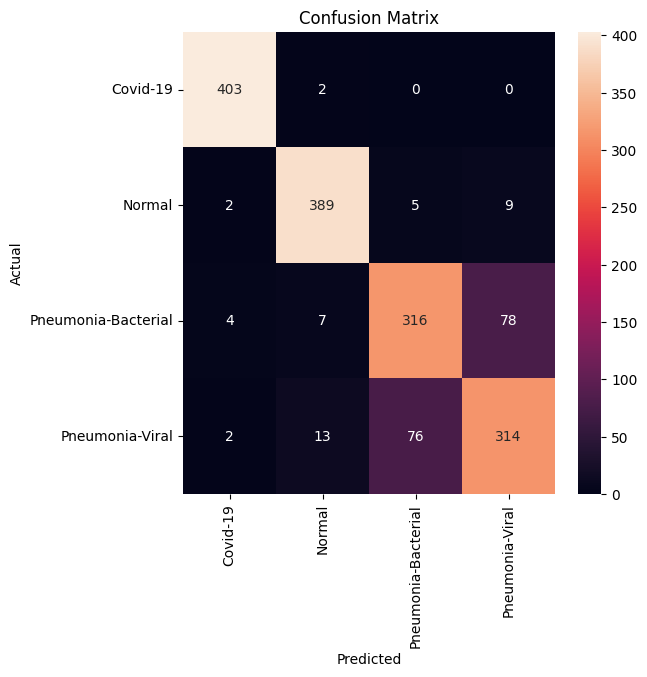

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [56]:
model.eval()

Beit(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
      (drop_

In [57]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [58]:
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print(all_probs.shape)
print(all_labels.shape)

(1620, 4)
(1620,)


In [59]:
num_classes = all_probs.shape[1]

all_labels_bin = label_binarize(
    all_labels,
    classes=list(range(num_classes))
)

In [60]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

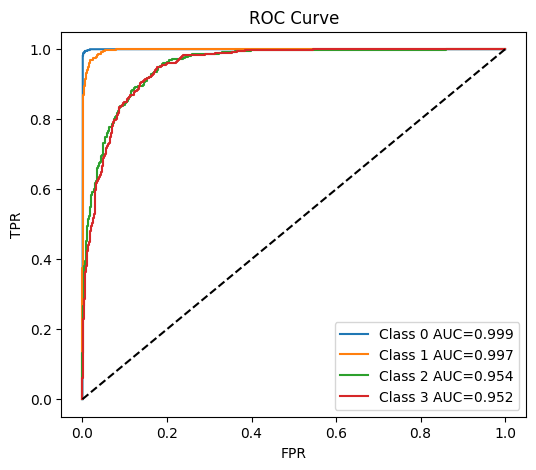

In [61]:
plt.figure(figsize=(6,5))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [62]:
import numpy as np

def beit_explain(model, img):
    model.eval()

    with torch.no_grad():
        features = model.forward_features(img)

    # Case 1: (B, C, H, W)
    if len(features.shape) == 4:
        heatmap = features.mean(dim=1).squeeze()

    # Case 2: (B, N, C)
    elif len(features.shape) == 3:
        tokens = features[:, 1:, :] if features.shape[1] > 1 else features
        tokens = tokens.mean(dim=2)

        size = int(np.sqrt(tokens.shape[1]))
        heatmap = tokens[:, :size*size].reshape(size, size).squeeze()

    else:
        raise ValueError("Unsupported feature shape")

    heatmap = heatmap.cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

In [63]:
images, labels = next(iter(test_loader))

img = images[0:1].to(device)

heatmap = beit_explain(model, img)

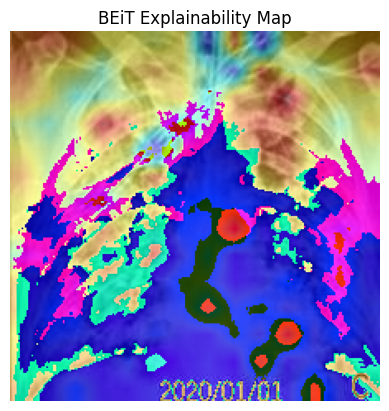

In [64]:
import cv2
import matplotlib.pyplot as plt

img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

overlay = heatmap_color * 0.4 + img_np * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("BEiT Explainability Map")
plt.axis('off')
plt.show()

In [65]:
import cv2
import numpy as np

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=500, s=8, p1=0.5):
        masks = []
        for _ in range(N):
            mask = (np.random.rand(s, s) < p1).astype(np.float32)
            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)
        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            mask_tensor = torch.tensor(mask).to(self.device)
            masked_img = image * mask_tensor
            masked_img = masked_img.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked_img), dim=1)

            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i].max() * masks[i]

        saliency /= len(masks)

        return saliency

In [66]:
rise = RISE(model, (224,224), device)

In [67]:
masks = rise.generate_masks(N=500, s=8, p1=0.5)

In [68]:
images, labels = next(iter(test_loader))
img = images[0].to(device)

saliency = rise.explain(img, masks)

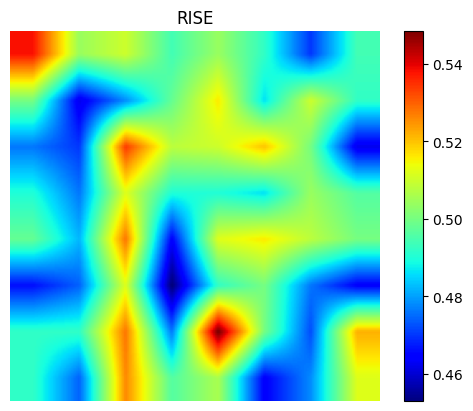

In [69]:
plt.imshow(saliency, cmap='jet')
plt.colorbar()
plt.title("RISE")
plt.axis('off')
plt.show()